<a href="https://colab.research.google.com/github/SallumAlsallum/ai-product-recommendation-system/blob/main/AI_based_product_recommendation_test_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

2 Connect to Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!tar -xvzf /content/drive/MyDrive/synerise_dataset.tar.gz -C /content

input/
input/search_query.parquet
input/remove_from_cart.parquet
input/relevant_clients.npy
input/page_visit.parquet
input/product_buy.parquet
input/add_to_cart.parquet
target/
target/active_clients.npy
target/propensity_new_sku.npy
target/popularity_propensity_sku.npy
target/propensity_sku.npy
target/validation_target.parquet
target/popularity_propensity_price.npy
target/popularity_propensity_category.npy
target/popularity_propensity_new_sku.npy
target/propensity_category.npy
target/propensity_price.npy
target/train_target.parquet
product_properties.parquet


In [4]:
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Correct paths for your tar extraction
INPUT_PATH = Path("/content/input")
PRODUCT_PATH = Path("/content/product_properties.parquet")

# Load core data
clients = np.load(INPUT_PATH / "relevant_clients.npy")
print(f"Loaded {len(clients):,} relevant clients")

events = {}
for name in ["product_buy", "add_to_cart", "remove_from_cart", "page_visit", "search_query"]:
    path = INPUT_PATH / f"{name}.parquet"
    events[name] = pd.read_parquet(path)
    print(f"Loaded {name}: {len(events[name]):,} rows")

product_props = pd.read_parquet(PRODUCT_PATH)
print(f"Loaded product_properties: {len(product_props):,} products")

print("\nAll data loaded successfully.")

Loaded 1,000,000 relevant clients
Loaded product_buy: 1,775,394 rows
Loaded add_to_cart: 5,674,064 rows
Loaded remove_from_cart: 1,937,170 rows
Loaded page_visit: 156,032,014 rows
Loaded search_query: 10,218,831 rows
Loaded product_properties: 1,260,365 products

All data loaded successfully.


Building features for 8000 clients...


Processing clients: 100%|██████████| 8000/8000 [37:27<00:00,  3.56it/s]


Dataset prepared - Train: (6000, 105), Test: (2000, 105)
Positive rate (churn proxy): 0.748

Training models...

Model Performance Comparison (AUROC - higher is better)
Logistic_Regression    : 1.0000
Random_Forest          : 1.0000
SVM                    : 0.9996


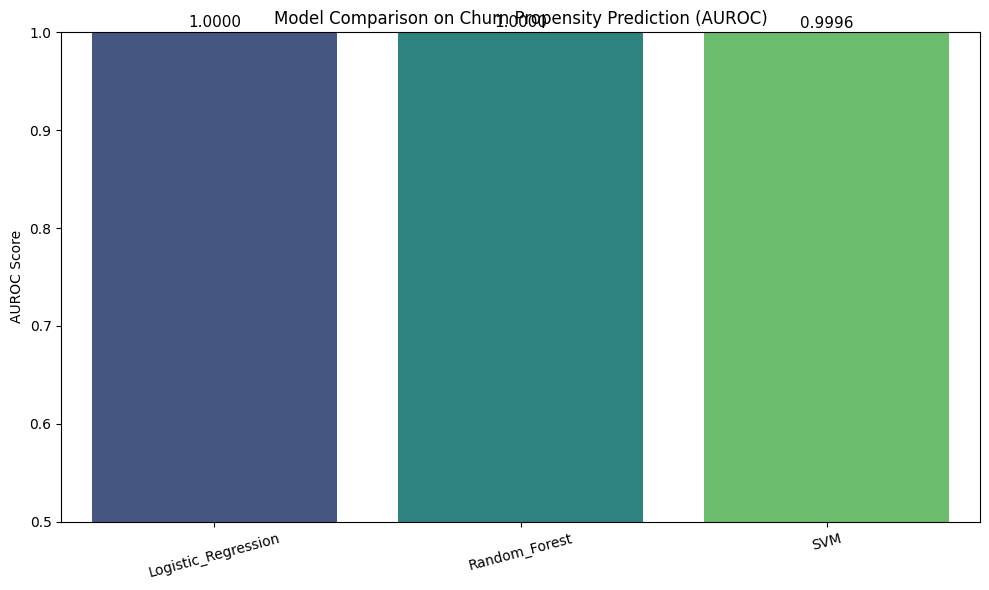

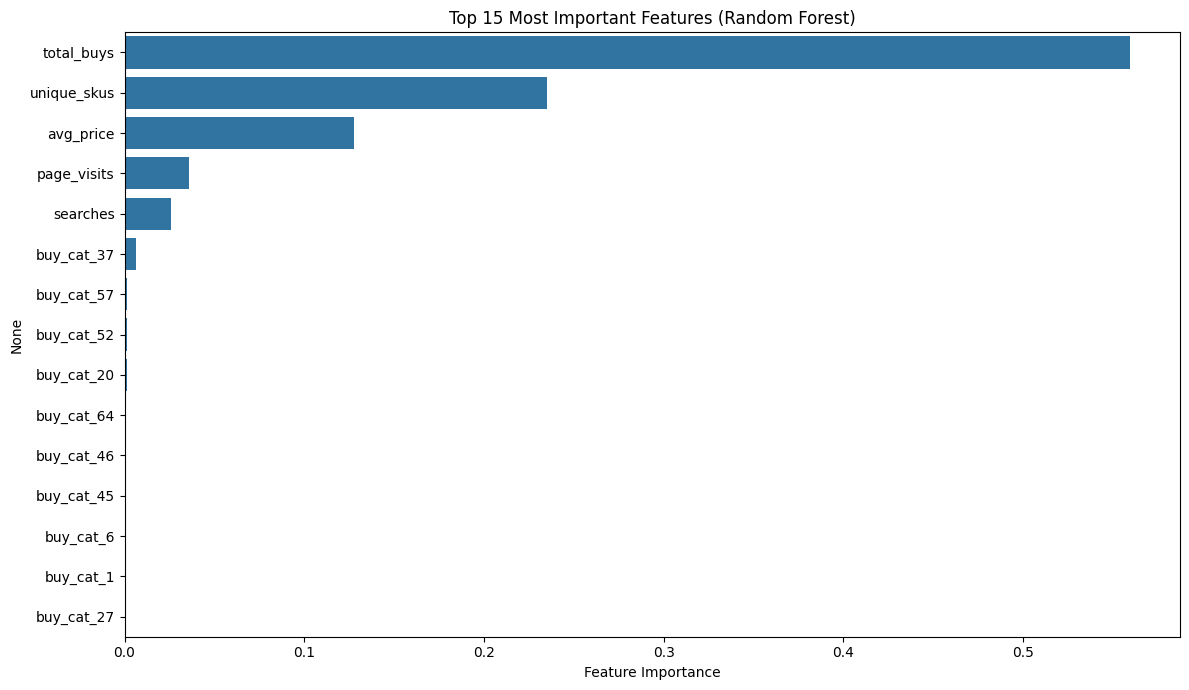


Evaluation completed. Graphs displayed above.


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

# Use small sample for fast test (~8-10 minutes)
sample_size = 8000
sample_clients = clients[:sample_size]

print(f"Building features for {sample_size} clients...")

# Merge buys with product info
buys = events["product_buy"].merge(product_props, on="sku", how="left")
buys = buys[buys["client_id"].isin(sample_clients)]

features = []
for cid in tqdm(sample_clients, desc="Processing clients"):
    row = {"client_id": cid}
    cb = buys[buys["client_id"] == cid]

    # Category purchase counts (strong signal for recommendation)
    for c in range(100):
        row[f"buy_cat_{c}"] = (cb["category"] == c).sum()

    row["total_buys"] = len(cb)
    row["unique_skus"] = cb["sku"].nunique()
    row["avg_price"] = cb["price"].mean() if not cb.empty else 0.0
    row["page_visits"] = len(events["page_visit"][events["page_visit"]["client_id"] == cid])
    row["searches"] = len(events["search_query"][events["search_query"]["client_id"] == cid])

    features.append(row)

df = pd.DataFrame(features)

# Simple target for evaluation (churn proxy: low purchase activity)
df["target"] = (df["total_buys"] <= 1).astype(int)

X = df.drop(["client_id", "target"], axis=1).fillna(0)
y = df["target"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Dataset prepared - Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Positive rate (churn proxy): {y.mean():.3f}")

# Scale features (important for Logistic Regression and SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train three models
results = {}

print("\nTraining models...")

# 1. Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict_proba(X_test_scaled)[:, 1]
results["Logistic_Regression"] = roc_auc_score(y_test, lr_pred)

# 2. Random Forest
rf = RandomForestClassifier(n_estimators=120, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict_proba(X_test)[:, 1]
results["Random_Forest"] = roc_auc_score(y_test, rf_pred)

# 3. SVM (with probability)
svm = SVC(kernel='rbf', probability=True, random_state=42, max_iter=500)
svm.fit(X_train_scaled, y_train)
svm_pred = svm.predict_proba(X_test_scaled)[:, 1]
results["SVM"] = roc_auc_score(y_test, svm_pred)

# Display results
print("\nModel Performance Comparison (AUROC - higher is better)")
for model_name, score in results.items():
    print(f"{model_name:22} : {score:.4f}")

# Visualizations
plt.figure(figsize=(10, 6))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette="viridis")
plt.title("Model Comparison on Churn Propensity Prediction (AUROC)")
plt.ylabel("AUROC Score")
plt.ylim(0.5, 1.0)
for i, v in enumerate(results.values()):
    plt.text(i, v + 0.005, f"{v:.4f}", ha='center', fontsize=11)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Feature importance from Random Forest (most interpretable here)
importances = rf.feature_importances_
top_idx = np.argsort(importances)[-15:][::-1]
top_features = X.columns[top_idx]
top_importances = importances[top_idx]

plt.figure(figsize=(12, 7))
sns.barplot(x=top_importances, y=top_features)
plt.title("Top 15 Most Important Features (Random Forest)")
plt.xlabel("Feature Importance")
plt.tight_layout()
plt.show()

print("\nEvaluation completed. Graphs displayed above.")